In [79]:
import sys
import gmsh
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, io, plot
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element, mixed_element
from petsc4py import PETSc

from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, rhs, sym, sqrt,
                 TestFunctions, TrialFunctions, CellDiameter)


In [80]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()

domain, cell_tags, facet_tags = io.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
topology, cell_type, geom = plot.vtk_mesh(domain) 

grid = pv.UnstructuredGrid(topology, cell_type, geom)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


In [81]:
# Future task: into a helper function
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.open(str(meshfile))

phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {
    gmsh.model.getPhysicalName(dim, tag): tag for dim, tag in phy_groups
}
print(name_to_id)

gmsh.finalize()

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}


In [82]:
# Function spaces for v and p
elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

V = fem.functionspace(domain, elem_u)
Q = fem.functionspace(domain, elem_p)

# Temporal parameters
t = 0.0
T = 10.0
num_steps = 200
dt = T / num_steps
time_steps = np.arange(t, T, dt)

# Trial and test functions
u = TrialFunction(V)
v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

# Functions
u_n = Function(V)
u_tent = Function(V)
u_new = Function(V)
p_n = Function(Q)
p_new = Function(Q)
f = Constant(domain, PETSc.ScalarType((0.0, 0.0)))

# Define strain-rate tensor
def epsilon(u):
    return sym(nabla_grad(u))

# Define stress tensor
def sigma(u, p):
    return 2 * mu * epsilon(u) - p * Identity(len(u))

u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(domain)
f = Constant(domain, PETSc.ScalarType((0, 0)))
k = Constant(domain, PETSc.ScalarType(dt))
mu = Constant(domain, PETSc.ScalarType(1.5e-4))
rho = Constant(domain, PETSc.ScalarType(1.2))

In [83]:
# Define the variational problem for the first step
p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(mu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx

a1 = form(lhs(F1))
L1 = form(rhs(F1))

# Define variational problem for step 2
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_new) * q * dx)

# Define variational problem for step 3
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_new, v) * dx - k * dot(nabla_grad(p_new - p_n), v) * dx)


In [84]:
# No slip conditions
zero = Function(V)
zero.x.array[:] = 0.0

def create_bcs(V: fem.FunctionSpace, facet_tags, name_to_id, zero, tags):
    fdim = V.mesh.topology.dim - 1
    bcs = []
    for name in tags:
        dofs = fem.locate_dofs_topological(V, fdim, facet_tags.find(name_to_id[name]))
        bcs.append(fem.dirichletbc(zero, dofs))
    return bcs

obstacle_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
no_slip_bcs = create_bcs(V, facet_tags, name_to_id, zero, obstacle_names)

# Inflow boundary
inflow_tag = name_to_id["Inflow"]

fdim = domain.topology.dim - 1
inflow_facets = facet_tags.find(inflow_tag)
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)

inflow_profile = Function(V)

x = V.tabulate_dof_coordinates().T
inflow_dofs_coords = x[:, inflow_dofs]

y_centered = (inflow_dofs_coords[1] - y_lim / 2.0) / (y_lim / 2.0)
u_val = 4.0 * (1 - y_centered) * y_centered

inflow_profile.x.array[:] = 0.0
inflow_profile.x.array[inflow_dofs * 2] = u_val

bc_in = fem.dirichletbc(inflow_profile, inflow_dofs)

p_out = Function(Q)
p_out.x.array[:] = 0.0

outflow_tag = name_to_id["Outflow"]
outflow_dofs = fem.locate_dofs_topological(Q, fdim, facet_tags.find(outflow_tag))

bc_out = fem.dirichletbc(p_out, outflow_dofs)

# bcs summary
velocity_bcs = [bc_in] + no_slip_bcs
pressure_bcs = [bc_out]

Converged after 6 iterations.
Final L2 err = 1.32e-08


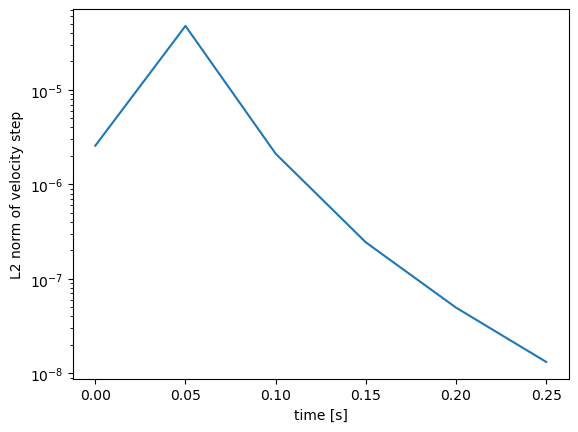

In [85]:
# Set up and solve
tentative_velocity_problem = LinearProblem(a1, L1, velocity_bcs, u_tent, 
                                           petsc_options={"ksp_type": "gmres"})
pressure_problem = LinearProblem(a2, L2, pressure_bcs, p_new)
velocity_correction_problem = LinearProblem(a3, L3, velocity_bcs, u_new)

# Error form
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V) 
l2_norm_squared = form(inner(u_diff, u_diff) * dx)
l2_errors = np.zeros(num_steps)
it_conv = np.inf

for idx, t_i in enumerate(time_steps):
    t = t_i
    tentative_velocity_problem.solve()
    pressure_problem.solve()
    velocity_correction_problem.solve()
    u_diff.x.array[:] = u_new.x.array - u_n.x.array
    l2_errors[idx] = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    
    if t_i > time_steps[0]:
        if abs(l2_errors[idx] - l2_errors[idx - 1]) < 1e-7:
            it_conv = idx
            print(f"Converged after {idx + 1} iterations.")
            print(f"Final L2 err = {l2_errors[it_conv]:.2e}")
            
            break
    u_n.x.array[:] = u_new.x.array
    p_n.x.array[:] = p_new.x.array
    sys.stdout.flush()


if it_conv == np.inf:
    print(f"Reached max number of iterations ({num_steps}). L2 Error: {l2_errors[-1]:.2e}")

if it_conv == np.inf:
    plt.semilogy(time_steps, l2_errors)
else:
    plt.semilogy(time_steps[0:it_conv+1], l2_errors[0:it_conv+1])
plt.xlabel("time [s]")
plt.ylabel("L2 norm of velocity step")
sys.stdout.flush()


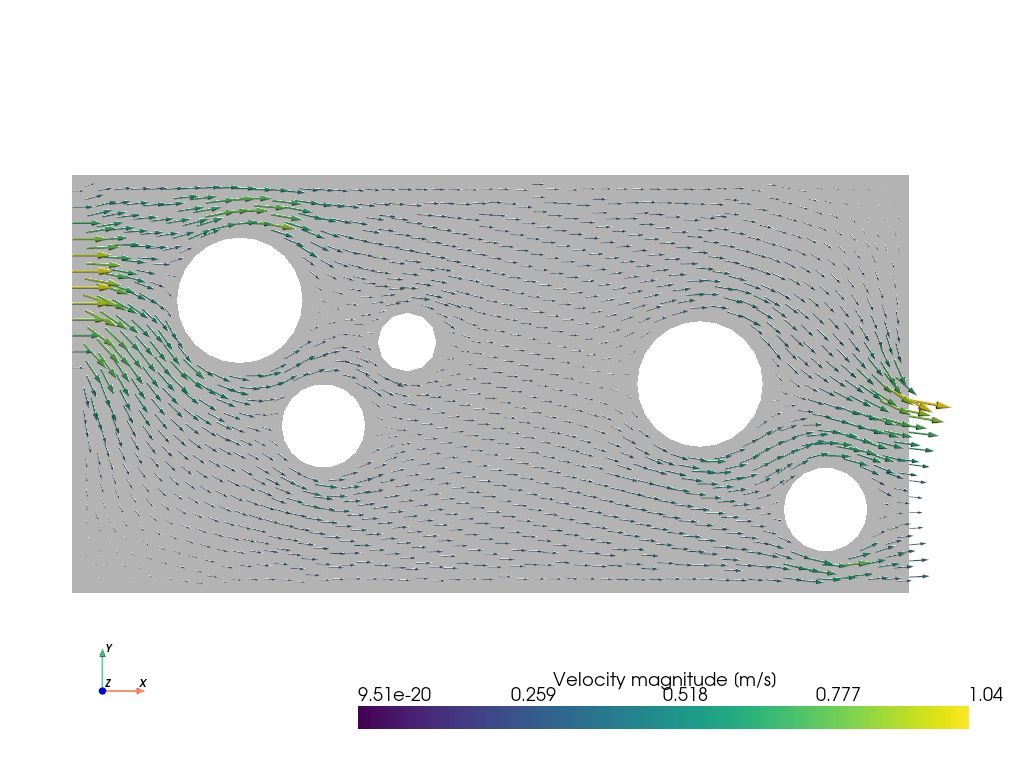

In [86]:
# Visualize solution
dom_cell = domain.basix_cell()
V_u_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))

u_vis = Function(V_u_vis)
u_vis.interpolate(u_new)

# Visualize
wind2d = u_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
wind_plot_indices = np.arange(0, grid.n_points, 1) # less dense plot
subset = grid.extract_points(wind_plot_indices, include_cells=False)
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Velocity magnitude [m/s]"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.zoom_camera(1.3)
pl.show_axes()
pl.show()

In [87]:
# Consider initial forward sim result as correct data
u_true = fem.Function(V)
u_true = u_new.copy()

# Wind field in 2D and 3D
wind2d = u_new.x.array.reshape(-1, 2)

# Get random set of wind measurements
p = 100
n = len(wind2d)
rng = np.random.default_rng()
m_ids = rng.choice(np.arange(n+1), p, replace=False)

m = np.zeros_like(wind2d)
m[m_ids] = wind2d[m_ids]
m = m.reshape((-1, ))

In [88]:
# Prepare function space
mixed_elem = mixed_element([elem_u, elem_p])
W = fem.functionspace(domain, mixed_elem)

nu = Constant(domain, 1e-2)

(u, p) = TrialFunctions(W)
(v, q) = TestFunctions(W)

In [89]:
sol = fem.Function(W)
u_sol, p_sol = sol.sub(0), sol.sub(1)

u_prev = Function(V)
p_prev = Function(Q)

u_prev.x.array[:] = 0.0
p_prev.x.array[:] = 0.0

max_picard = 50
tol_picard = 1e-8
omega = 0.5

for k in range(max_picard):
    # SUPG
    h = CellDiameter(domain)
    abs_u_prev = sqrt(dot(u_prev, u_prev)) + 1e-12
    tau = 1.0 / ( (2.0 * abs_u_prev) / h + 4.0 * nu / (h*h) + 1e-8 )
    R_m = dot(u_prev, nabla_grad(u_prev)) - nu*div(nabla_grad(u_prev)) + nabla_grad(p_prev)
    supg = tau * inner(dot(u_prev, nabla_grad(v)), R_m) * dx

    # Picard linearization
    a_nav_stokes = ( nu * inner(nabla_grad(u), nabla_grad(v))
                 + inner(dot(u_prev, nabla_grad(u)), v)
                 - inner(p, div(v))
                 + inner(div(u), q) ) * dx
    Rm_trial = dot(u_prev, nabla_grad(u)) - nu * div(nabla_grad(u)) + nabla_grad(p)
    supg = tau * inner(dot(u_prev, nabla_grad(v)), Rm_trial) * dx

    a_picard = a_nav_stokes + supg

    L_picard = inner(fem.Constant(domain, PETSc.ScalarType((0.0, 0.0))), v) * dx

    prob = LinearProblem(a_picard, L_picard, velocity_bcs + pressure_bcs, sol,
                         petsc_options={"ksp_type": "gmres", "pc_type": "ilu",
                                        "ksp_rtol": 1e-6, "ksp_max_it": 500})
    prob.solve()

    u_next = sol.sub(0).collapse()
    p_next = sol.sub(1).collapse()

    # Dämpfung
    u_next.x.array[:] = (1 - omega) * u_prev.x.array + omega * u_next.x.array

    err = np.linalg.norm(u_next.x.array - u_prev.x.array)
    print(f"Iteration {k}: error = {err:.3e}")
    if err < tol_picard:
        print("Picard converged.")
        break

    u_prev.x.array[:] = u_next.x.array
    p_prev.x.array[:] = p_next.x.array

u_forward = u_next.copy()
p_forward = p_next.copy()

Iteration 0: error = 1.977e+04
Iteration 1: error = 9.886e+03
Iteration 2: error = 4.943e+03
Iteration 3: error = 2.470e+03
Iteration 4: error = 1.235e+03
Iteration 5: error = 6.262e+02
Iteration 6: error = 3.078e+02
Iteration 7: error = 2.168e+02
Iteration 8: error = 1.186e+02
Iteration 9: error = 6.743e+01
Iteration 10: error = 4.727e+01
Iteration 11: error = 3.023e+01
Iteration 12: error = 2.705e+01
Iteration 13: error = 1.943e+01
Iteration 14: error = 1.926e+01
Iteration 15: error = 6.125e+01
Iteration 16: error = 4.281e+01
Iteration 17: error = 2.057e+01
Iteration 18: error = 2.198e+01
Iteration 19: error = 1.972e+01
Iteration 20: error = 2.455e+01
Iteration 21: error = 3.257e+01
Iteration 22: error = 1.426e+01
Iteration 23: error = 2.863e+01
Iteration 24: error = 1.992e+01
Iteration 25: error = 1.557e+01
Iteration 26: error = 1.544e+01
Iteration 27: error = 2.617e+01
Iteration 28: error = 1.472e+01
Iteration 29: error = 1.206e+01
Iteration 30: error = 1.203e+01
Iteration 31: erro

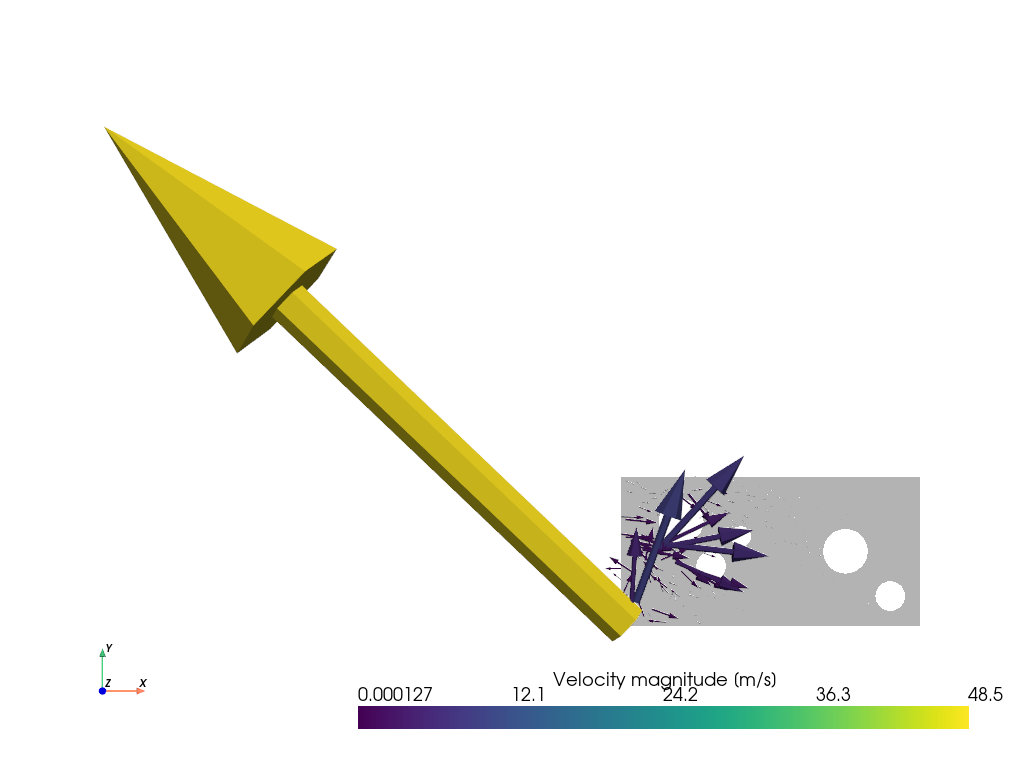

In [90]:
u_vis = Function(V_u_vis)
u_vis.interpolate(u_next)

# Visualize
wind2d = u_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
wind_plot_indices = np.arange(0, grid.n_points, 5) # less dense plot
subset = grid.extract_points(wind_plot_indices, include_cells=False)
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Velocity magnitude [m/s]"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.set_scale(1.0)
pl.zoom_camera(1.3)
pl.show_axes()
pl.show()